# Latency Bench Plotting

This notebook calls the latency bench plotting API directly so suite inputs, interpolation, labels, and bar style can be edited in one place.

In [1]:
%load_ext autoreload
%autoreload 2
from dataclasses import dataclass
from pathlib import Path
import re
import sys


def find_repo_root(start: Path | None = None) -> Path:
    path = Path.cwd() if start is None else start
    for candidate in (path.resolve(), *path.resolve().parents):
        if (candidate / "tools" / "latency_bench").is_dir():
            return candidate
    raise RuntimeError("failed to find Vortex repository root")


REPO_ROOT = find_repo_root()
LATENCY_DIR = REPO_ROOT / "analysis_workspace" / "latency_on_hw"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from IPython.display import Image, display
from tools.latency_bench.compose import LatencyScaleRule
from tools.latency_bench.estimate import LatencyEstimateOptions, evaluate_latency_estimator_groups
from tools.latency_bench.plot import (
    SuiteBarPlotOptions,
    prepare_suite_bar_data_versions,
    plot_suite_bar_grid,
    write_suite_bar_data_csvs,
)
from tools.latency_bench.suite import load_suite

REPO_ROOT, LATENCY_DIR

(PosixPath('/home/jaeyongjang/project.local/vortex'),
 PosixPath('/home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw'))

In [2]:
# outputs_main raw DBs are shared by the main and main_all suite plots.
RAW_DBS_OUTPUT_MAIN = [
    LATENCY_DIR / "outputs_main/naive_simd/raw_db.csv",
    LATENCY_DIR / "outputs_main/naive_gemm_tcol32/raw_db.csv",
    LATENCY_DIR / "outputs_main/improve_tcol32/raw_db.csv",
]

# Original workload suites are used for model-level comparison. Generated/merged suites are execution shards.
SUITE_FILE_ORDER = [
    "llama2_7b_prefill_C1.yaml",
    "llama2_7b_prefill_C2.yaml",
    "llama2_7b_prefill_C3.yaml",
    "llama2_7b_prefill_C4_alone.yaml",
    "llama2_7b_prefill_C4_fused.yaml",
    "llama2_7b_generation_C1.yaml",
    "llama2_7b_generation_C2.yaml",
    "llama2_7b_generation_C3.yaml",
    "llama2_7b_generation_C4_alone.yaml",
    "llama2_7b_generation_C4_fused.yaml",
]


def suite_paths(tag: str) -> list[Path]:
    return [LATENCY_DIR / "suites" / tag / filename for filename in SUITE_FILE_ORDER]


# Measurement and axis controls.
METRIC = "p50_us"
SELECT = "latest"
MISSING = "nan"  # Keep missing data visible while interpolation is enabled.
X_AXIS = "seq_len"
HUE_AXIS = "variant"
ROW_AXIS = "stage"
COL_AXIS = "batch"
STACKED = True
STACK_BY = "name"
VALUE_LABELS = True
RELATIVE = True
RELATIVE_SCOPE = "x_tick"  # global, subplot, or x_tick
SHARE_Y = False

# Optional row filters are applied after compose/estimate and before aggregation.
# Examples:
# PLOT_ROW_FILTERS = (lambda df: df["kind"].eq("gemm"),)
# PLOT_ROW_FILTERS = (lambda df: df["backend"].eq("sgemm_tcu"),)
PLOT_ROW_FILTERS = ()

# Interpolation/estimation controls. The plot uses measured + estimated data when enabled.
LATENCY_ESTIMATE = LatencyEstimateOptions(
    model="auto_shape",
    min_train_rows=3,
    fallback="nearest_scale",
    warn_extrapolation=False,
)

# Presentation controls. Values not listed here keep their raw DB/suite text.
AXIS_LABEL_MAP = {
    "seq_len": "sequence length",
    "variant": "variant",
    "stage": "stage",
    "batch": "batch",
    "name": "kernel",
}
LABEL_MAPS = {
    "stage": {"prefill": "Prefill", "generation": "Generation"},
    "variant": {
        "all_fpint_gemm_improve_alone_layout_spinquant": "C4-alone",
        "all_fpint_gemm_improve_fused_layout_spinquant": "C4-fused",
        "all_fpint_gemm_naive_spinquant": "C3",
        "all_sgemm_tcu_spinquant": "C1",
        "attn_sgemm_tcu_fpint_gemm_naive_spinquant": "C2",
    },
    "name": {},
}
VALUE_ORDERS = {
    "variant": [
        "all_sgemm_tcu_spinquant",
        "attn_sgemm_tcu_fpint_gemm_naive_spinquant",
        "all_fpint_gemm_naive_spinquant",
        "all_fpint_gemm_improve_alone_layout_spinquant",
        "all_fpint_gemm_improve_fused_layout_spinquant",
    ],
}

FIGURE_TITLE = None
SUBPLOT_TITLE_TEMPLATE = "{row_axis_label}={row_value_label}, {col_axis_label}={col_value_label}"
X_LABEL = "sequence length"
Y_LABEL = None
LEGEND_TITLE = "kernel" if STACKED else "variant"
LEGEND_POSITION = "right"  # right, bottom, top, or none
LEGEND_NCOL = None

# Style controls. Change these and rerun a plot section to iterate quickly.
BAR_PALETTE = (
    "#0B3954",
    "#087E8B",
    "#FF5A5F",
    "#C81D25",
    "#F5B700",
    "#6A4C93",
    "#2E933C",
    "#F86624",
)
# HUE_STACK_CMAPS = ("turbo", "nipy_spectral", "gist_rainbow", "hsv", "tab20")
HUE_STACK_CMAPS = ("turbo", "turbo", "turbo", "turbo", "turbo")
STACK_CMAP_MIN = 0.02
STACK_CMAP_MAX = 0.98
BAR_EDGECOLOR = "white"  # Use "none" for no borders, or "#333333" for stronger separation.
BAR_LINEWIDTH = 0.25
BAR_ALPHA = 1.0
GROUPED_BAR_GAP = 0.04
VALUE_LABEL_ROTATION = 90.0
VALUE_LABEL_FONTSIZE = 7.0
X_TICK_LABEL_MODE = "group"  # group or bar
X_TICK_LABEL_ROTATION = 0.0
X_TICK_LABEL_HA = "center"  # center, left, or right

# Optional raw DB latency normalization rules. When non-empty, the notebook writes
# both unscaled CSVs and *_scaled.csv files, and plots the scaled+estimated values.
LATENCY_SCALE_RULES = [
    # LatencyScaleRule("sgemm_tcu_area_norm", {"app": "sgemm_tcu"}, 1.0),
    # LatencyScaleRule("attn_tcu_area_norm", {"app": "sgemm_tcu", "name": re.compile(r"attn_(qkT|pv)")}, 1.0),
]

In [3]:
@dataclass
class PlotRunResult:
    tag: str
    out_dir: Path
    suites: list
    options: SuiteBarPlotOptions
    versions: object
    composed: object
    plot_data: object
    stack_data: object


def run_suite_plot(
    tag: str,
    *,
    out_name: str | None = None,
    figure_title: str | None = None,
    row_filters: tuple | None = None,
) -> PlotRunResult:
    suites_in = suite_paths(tag)
    out_dir = LATENCY_DIR / "outputs_main" / "figures_notebook" / (out_name or tag)
    missing_inputs = [path for path in [*suites_in, *RAW_DBS_OUTPUT_MAIN] if not path.exists()]
    if missing_inputs:
        raise FileNotFoundError("missing plot inputs:\n" + "\n".join(str(path) for path in missing_inputs))

    suites = [load_suite(path, repo_root=REPO_ROOT) for path in suites_in]
    options = SuiteBarPlotOptions(
        raw_dbs=tuple(RAW_DBS_OUTPUT_MAIN),
        out_dir=out_dir,
        metric=METRIC,
        select=SELECT,
        missing=MISSING,
        x=X_AXIS,
        hue=HUE_AXIS,
        row=ROW_AXIS,
        col=COL_AXIS,
        stacked=STACKED,
        stack_by=STACK_BY,
        value_labels=VALUE_LABELS,
        relative=RELATIVE,
        relative_scope=RELATIVE_SCOPE,
        share_y=SHARE_Y,
        legend_position=LEGEND_POSITION,
        legend_ncol=LEGEND_NCOL,
        figure_title=figure_title if figure_title is not None else FIGURE_TITLE,
        subplot_title_template=SUBPLOT_TITLE_TEMPLATE,
        x_label=X_LABEL,
        y_label=Y_LABEL,
        legend_title=LEGEND_TITLE,
        axis_label_map=AXIS_LABEL_MAP,
        label_maps=LABEL_MAPS,
        value_orders=VALUE_ORDERS,
        stack_legend_scope="hue",
        latency_scale_rules=tuple(LATENCY_SCALE_RULES),
        latency_estimate=LATENCY_ESTIMATE,
        row_filters=tuple(PLOT_ROW_FILTERS if row_filters is None else row_filters),
        palette=BAR_PALETTE,
        hue_stack_cmaps=HUE_STACK_CMAPS,
        stack_cmap_min=STACK_CMAP_MIN,
        stack_cmap_max=STACK_CMAP_MAX,
        bar_edgecolor=BAR_EDGECOLOR,
        bar_linewidth=BAR_LINEWIDTH,
        bar_alpha=BAR_ALPHA,
        grouped_bar_gap=GROUPED_BAR_GAP,
        value_label_rotation=VALUE_LABEL_ROTATION,
        value_label_fontsize=VALUE_LABEL_FONTSIZE,
        x_tick_label_mode=X_TICK_LABEL_MODE,
        x_tick_label_rotation=X_TICK_LABEL_ROTATION,
        x_tick_label_ha=X_TICK_LABEL_HA,
    )

    versions = prepare_suite_bar_data_versions(suites, options)
    plot_input = versions.final
    for suffix, data in versions.csv_items():
        write_suite_bar_data_csvs(data, out_dir, suffix=suffix)
    plot_suite_bar_grid(plot_input.plot_data, plot_input.stack_data, options)

    result = PlotRunResult(
        tag=tag,
        out_dir=out_dir,
        suites=suites,
        options=options,
        versions=versions,
        composed=plot_input.composed,
        plot_data=plot_input.plot_data,
        stack_data=plot_input.stack_data,
    )
    print(f"wrote {out_dir}")
    return result


def display_plot(result: PlotRunResult):
    figure_path = result.out_dir / f"bar_total_{result.options.metric}.png"
    display(Image(filename=str(figure_path)))
    return figure_path

## outputs_main + suites/main

This section plots the main measured sweep and fills missing cases with the interpolation/estimation option above.

wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/main


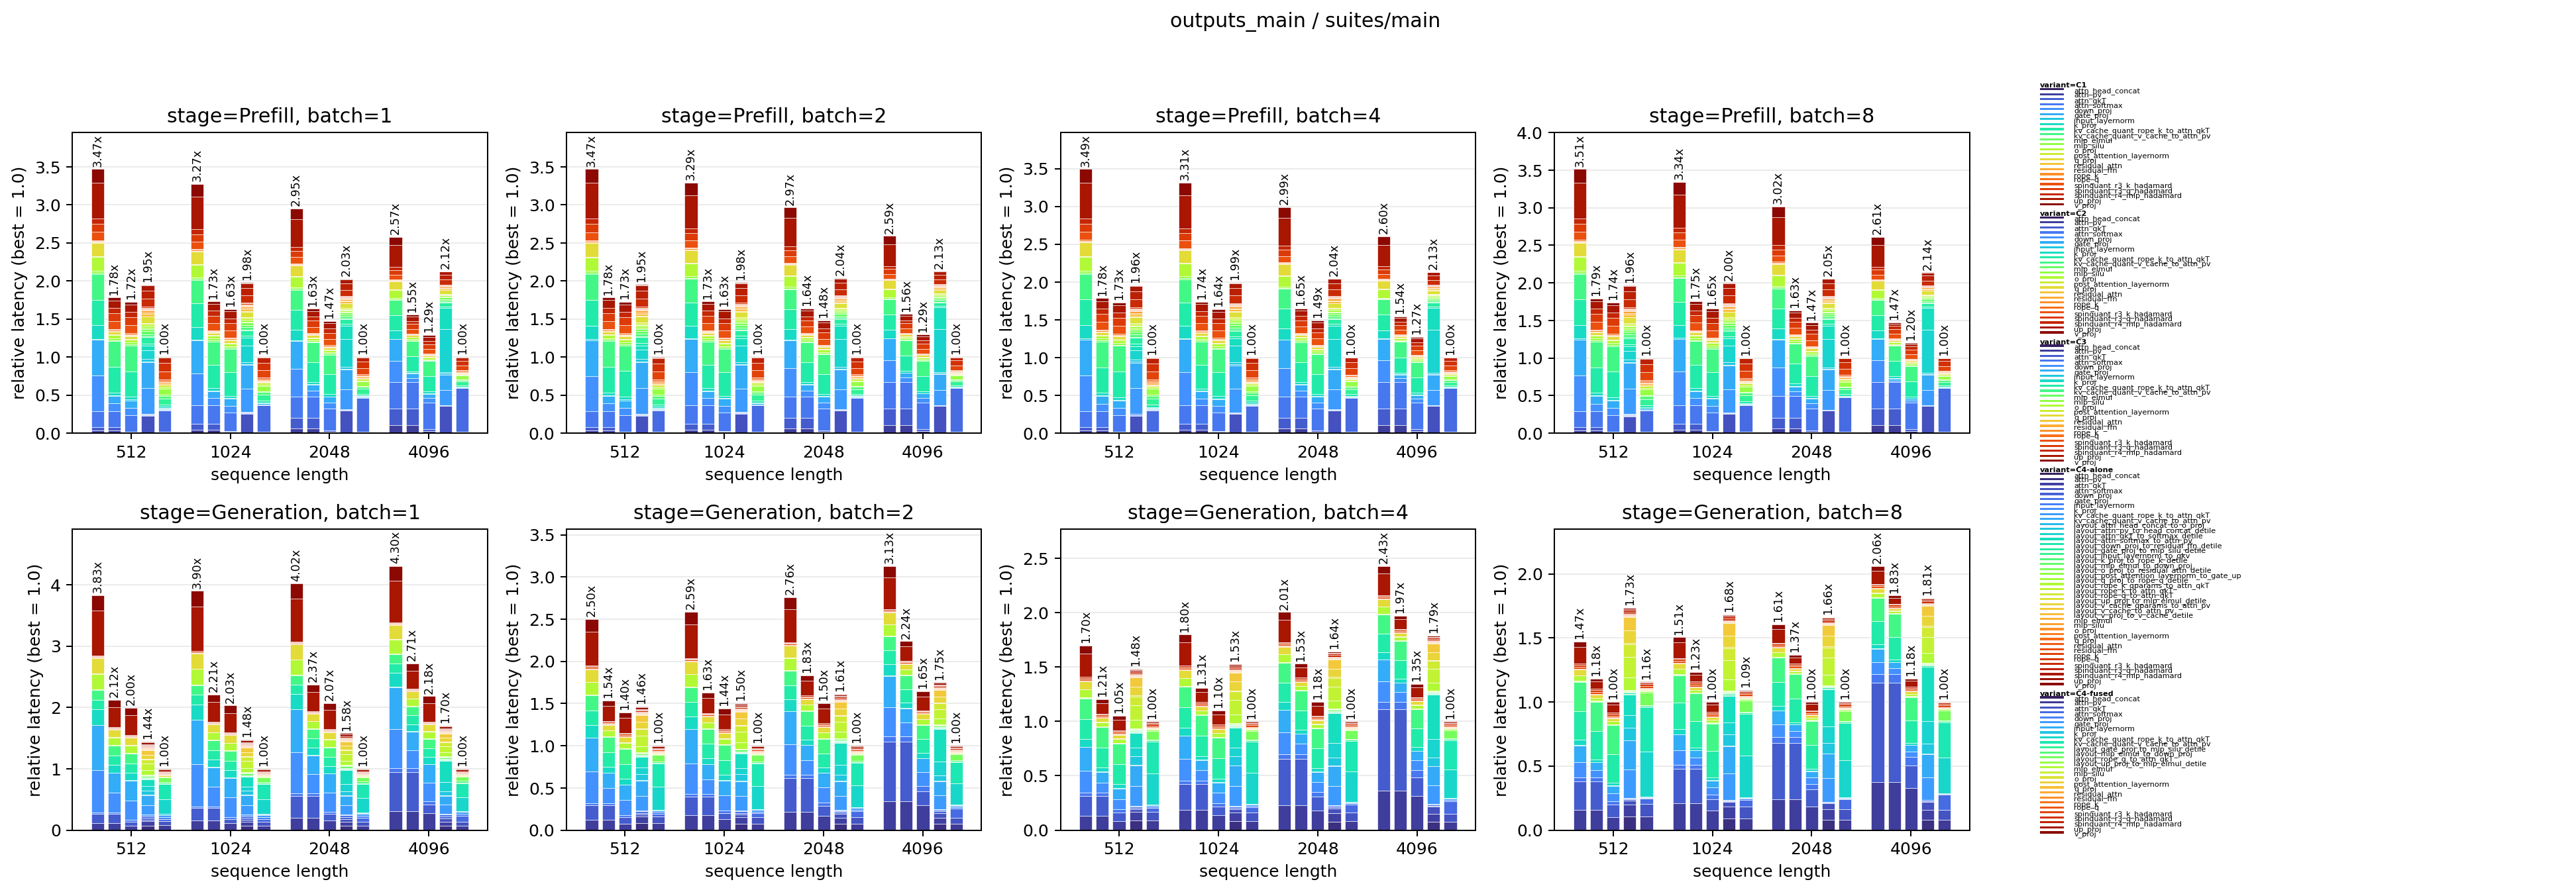

,metric,stage,seq_len,batch,variant,total_latency_us,case_count,pass_case_count,estimated_case_count,missing_case_count,...,estimate_basis,estimate_selected_by,estimate_cv_mape,estimate_train_mape,estimate_group,estimate_mode,estimate_distance,estimate_source_case_id,estimate_source_raw_dbs,estimate_train_rows
0,p50_us,generation,512,1,all_fpint_gemm_improve_alone_layout_spinquant,3.556144e+07,43,43,0,0,...,,,,,,,,,,0
1,p50_us,generation,512,1,all_fpint_gemm_improve_fused_layout_spinquant,2.467474e+07,28,28,0,0,...,,,,,,,,,,0
2,p50_us,generation,512,1,all_fpint_gemm_naive_spinquant,4.924940e+07,24,24,0,0,...,,,,,,,,,,0
3,p50_us,generation,512,1,all_sgemm_tcu_spinquant,9.447358e+07,24,24,0,0,...,,,,,,,,,,0
4,p50_us,generation,512,1,attn_sgemm_tcu_fpint_gemm_naive_spinquant,5.240788e+07,24,24,0,0,...,,,,,,,,,,0


In [4]:
main_result = run_suite_plot("main", out_name="main", figure_title="outputs_main / suites/main")
display_plot(main_result)
main_result.plot_data.head()

## outputs_main + suites/main_all

This section uses the larger main_all suite set with the same outputs_main raw DB and interpolation settings.

wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/main_all


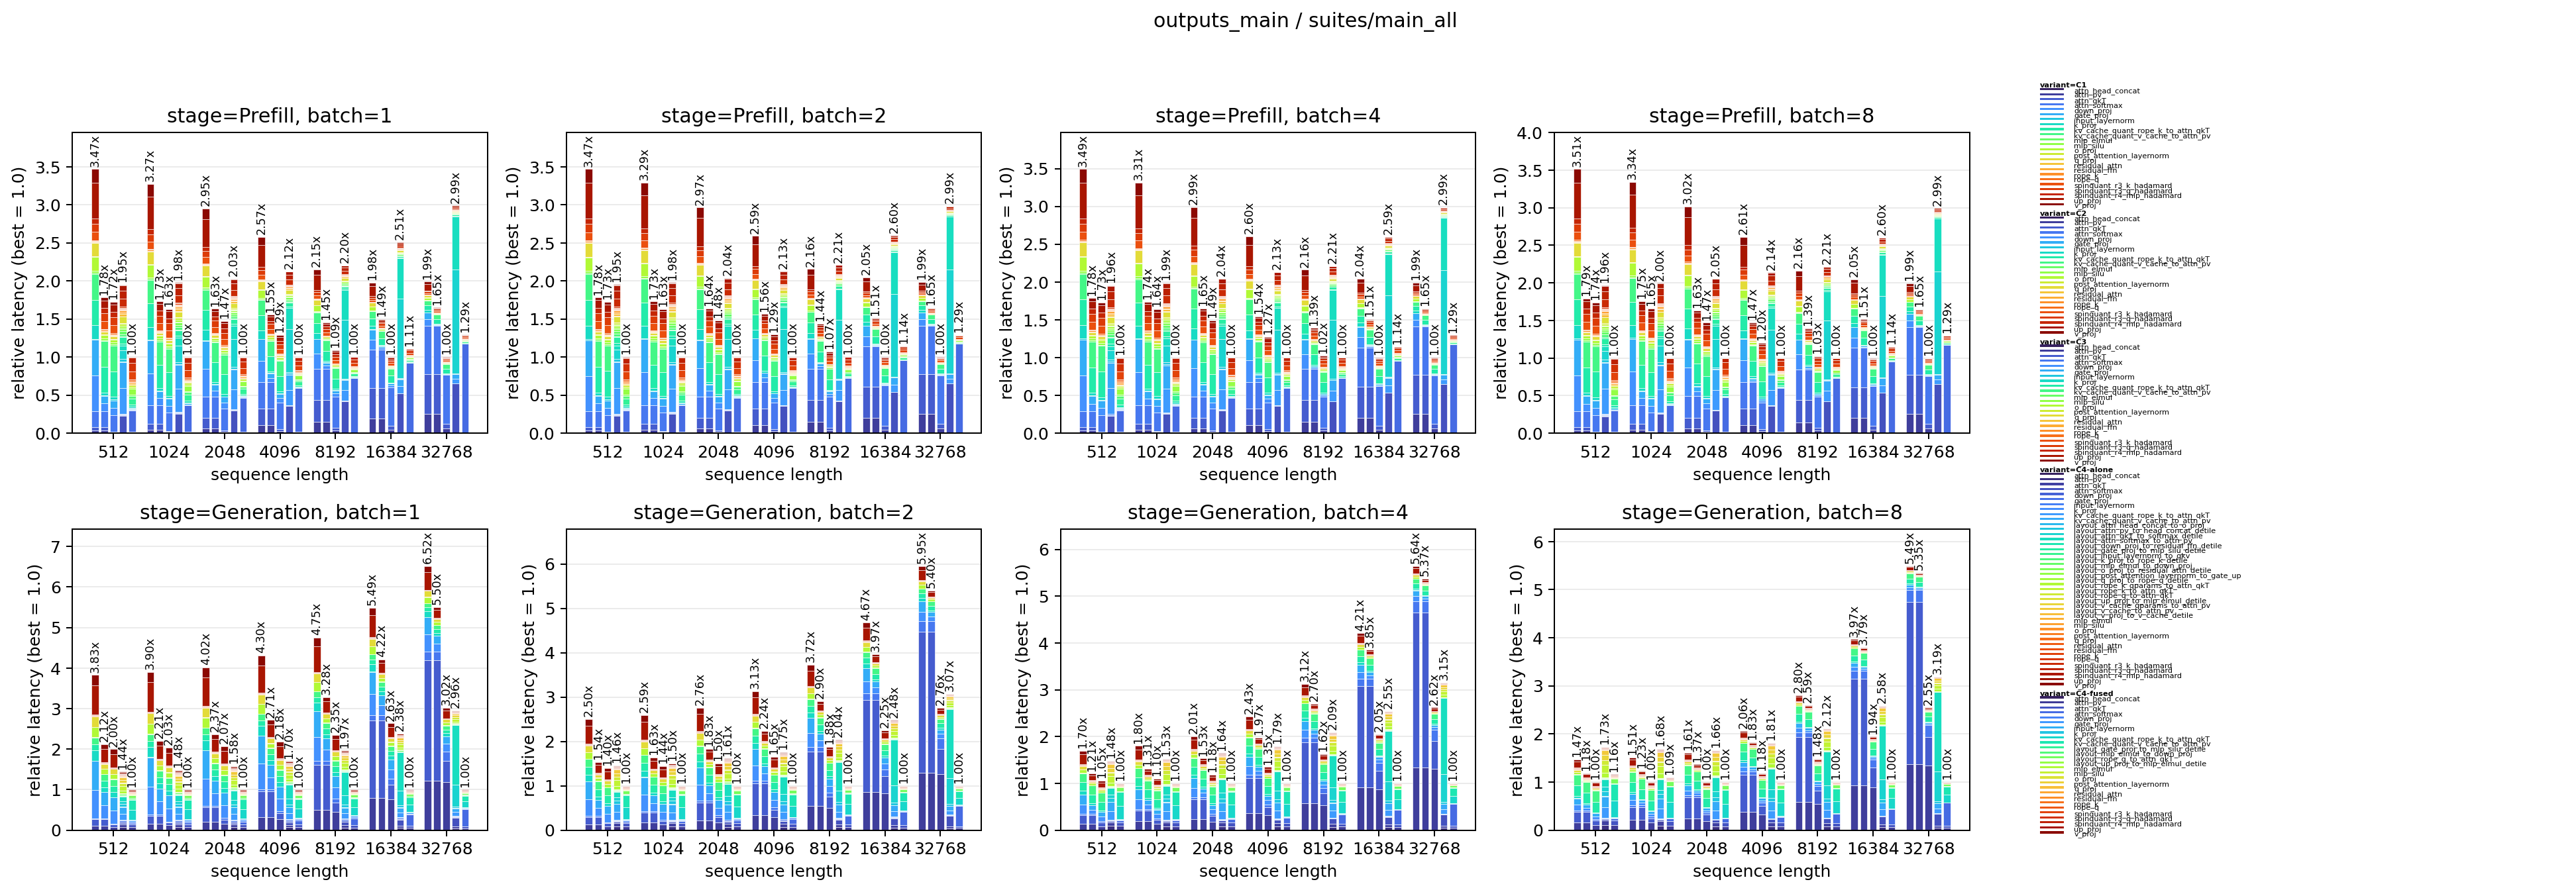

,metric,stage,seq_len,batch,variant,total_latency_us,case_count,pass_case_count,estimated_case_count,missing_case_count,...,estimate_basis,estimate_selected_by,estimate_cv_mape,estimate_train_mape,estimate_group,estimate_mode,estimate_distance,estimate_source_case_id,estimate_source_raw_dbs,estimate_train_rows
0,p50_us,generation,512,1,all_fpint_gemm_improve_alone_layout_spinquant,3.556144e+07,43,43,0,0,...,,,,,,,,,,0
1,p50_us,generation,512,1,all_fpint_gemm_improve_fused_layout_spinquant,2.467474e+07,28,28,0,0,...,,,,,,,,,,0
2,p50_us,generation,512,1,all_fpint_gemm_naive_spinquant,4.924940e+07,24,24,0,0,...,,,,,,,,,,0
3,p50_us,generation,512,1,all_sgemm_tcu_spinquant,9.447358e+07,24,24,0,0,...,,,,,,,,,,0
4,p50_us,generation,512,1,attn_sgemm_tcu_fpint_gemm_naive_spinquant,5.240788e+07,24,24,0,0,...,,,,,,,,,,0


In [5]:
main_all_result = run_suite_plot("main_all", out_name="main_all", figure_title="outputs_main / suites/main_all")
display_plot(main_all_result)
main_all_result.plot_data.head()

## GEMM Only Plots

These cells use the plot API `row_filters` override so only workload cases with `kind == "gemm"` are included in aggregation, stacked bars, and exported CSVs.

In [6]:
GEMM_ONLY_FILTERS = (lambda df: df["kind"].eq("gemm"),)

wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/main_gemm_only


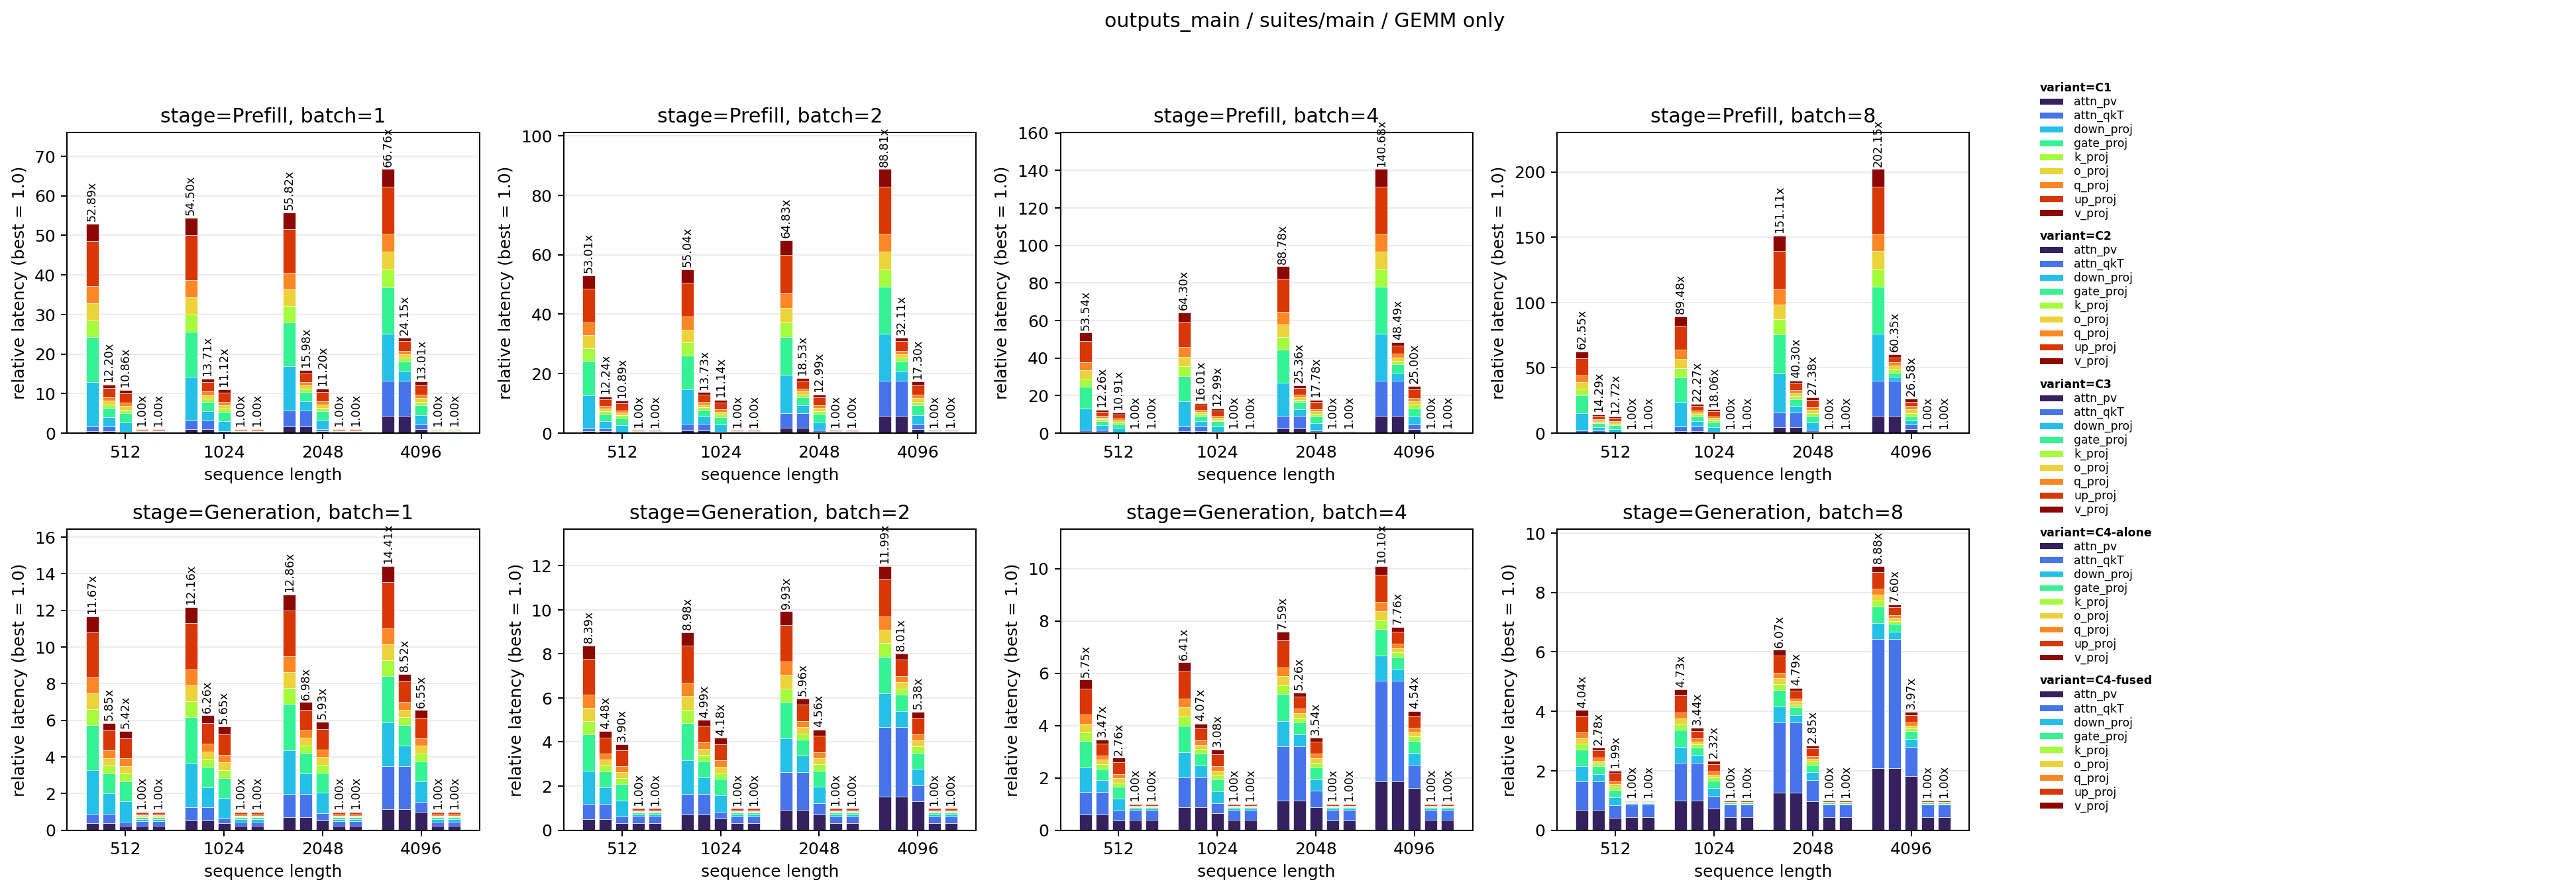

,metric,stage,seq_len,batch,variant,total_latency_us,case_count,pass_case_count,estimated_case_count,missing_case_count,...,estimate_basis,estimate_selected_by,estimate_cv_mape,estimate_train_mape,estimate_group,estimate_mode,estimate_distance,estimate_source_case_id,estimate_source_raw_dbs,estimate_train_rows
0,p50_us,generation,512,1,all_fpint_gemm_improve_alone_layout_spinquant,7.238311e+06,9,9,0,0,...,,,,,,,,,,0
1,p50_us,generation,512,1,all_fpint_gemm_improve_fused_layout_spinquant,7.238311e+06,9,9,0,0,...,,,,,,,,,,0
2,p50_us,generation,512,1,all_fpint_gemm_naive_spinquant,3.921379e+07,9,9,0,0,...,,,,,,,,,,0
3,p50_us,generation,512,1,all_sgemm_tcu_spinquant,8.443796e+07,9,9,0,0,...,,,,,,,,,,0
4,p50_us,generation,512,1,attn_sgemm_tcu_fpint_gemm_naive_spinquant,4.237226e+07,9,9,0,0,...,,,,,,,,,,0


In [7]:
main_gemm_only_result = run_suite_plot(
    "main",
    out_name="main_gemm_only",
    figure_title="outputs_main / suites/main / GEMM only",
    row_filters=GEMM_ONLY_FILTERS,
)
display_plot(main_gemm_only_result)
main_gemm_only_result.plot_data.head()

wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/main_all_gemm_only


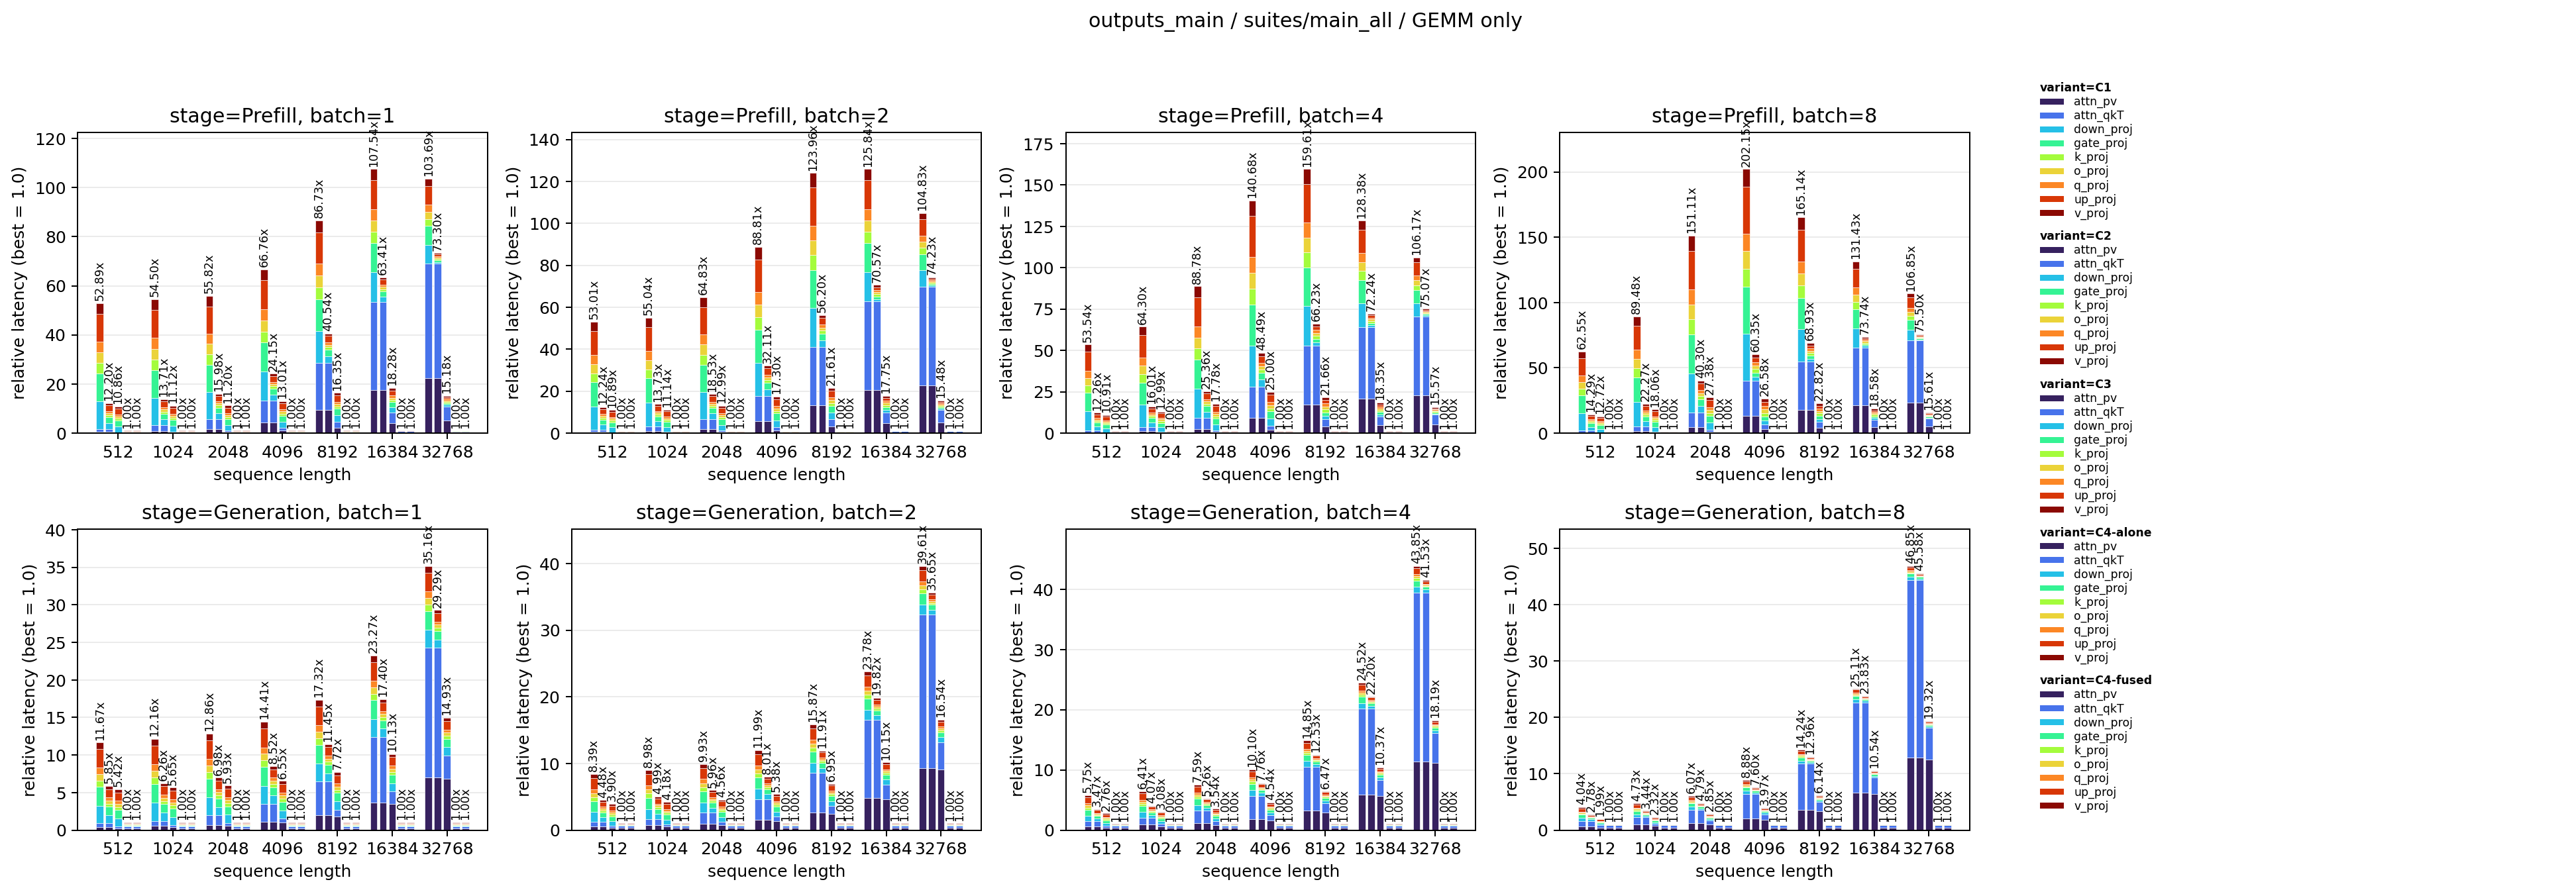

,metric,stage,seq_len,batch,variant,total_latency_us,case_count,pass_case_count,estimated_case_count,missing_case_count,...,estimate_basis,estimate_selected_by,estimate_cv_mape,estimate_train_mape,estimate_group,estimate_mode,estimate_distance,estimate_source_case_id,estimate_source_raw_dbs,estimate_train_rows
0,p50_us,generation,512,1,all_fpint_gemm_improve_alone_layout_spinquant,7.238311e+06,9,9,0,0,...,,,,,,,,,,0
1,p50_us,generation,512,1,all_fpint_gemm_improve_fused_layout_spinquant,7.238311e+06,9,9,0,0,...,,,,,,,,,,0
2,p50_us,generation,512,1,all_fpint_gemm_naive_spinquant,3.921379e+07,9,9,0,0,...,,,,,,,,,,0
3,p50_us,generation,512,1,all_sgemm_tcu_spinquant,8.443796e+07,9,9,0,0,...,,,,,,,,,,0
4,p50_us,generation,512,1,attn_sgemm_tcu_fpint_gemm_naive_spinquant,4.237226e+07,9,9,0,0,...,,,,,,,,,,0


In [8]:
main_all_gemm_only_result = run_suite_plot(
    "main_all",
    out_name="main_all_gemm_only",
    figure_title="outputs_main / suites/main_all / GEMM only",
    row_filters=GEMM_ONLY_FILTERS,
)
display_plot(main_all_gemm_only_result)
main_all_gemm_only_result.plot_data.head()

### debugging plot data

In [9]:
df_ = main_all_result.stack_data
df_ = df_[df_["variant"]=="all_fpint_gemm_improve_fused_layout_spinquant"]
df_ = df_[(df_["stage"]=="prefill") & (df_["batch"] == 8) & (df_["seq_len"] == 16384)]
print(df_.sort_values(by="total_latency_us"))

      metric    stage  seq_len  batch  \
7341  p50_us  prefill    16384      8   
7362  p50_us  prefill    16384      8   
7340  p50_us  prefill    16384      8   
7343  p50_us  prefill    16384      8   
7354  p50_us  prefill    16384      8   
7363  p50_us  prefill    16384      8   
7352  p50_us  prefill    16384      8   
7342  p50_us  prefill    16384      8   
7353  p50_us  prefill    16384      8   
7344  p50_us  prefill    16384      8   
7337  p50_us  prefill    16384      8   
7355  p50_us  prefill    16384      8   
7356  p50_us  prefill    16384      8   
7336  p50_us  prefill    16384      8   
7348  p50_us  prefill    16384      8   
7350  p50_us  prefill    16384      8   
7338  p50_us  prefill    16384      8   
7357  p50_us  prefill    16384      8   
7358  p50_us  prefill    16384      8   
7351  p50_us  prefill    16384      8   
7345  p50_us  prefill    16384      8   
7347  p50_us  prefill    16384      8   
7361  p50_us  prefill    16384      8   
7346  p50_us  pr